In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# WORKING ON RAW & DUPLICATE DATA

In [2]:
N = 100

folder_path = r"S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026"

all_files = {
    1: "Joint_1_Clean.csv",
    2: "Joint_2_Clean.csv",
    3: "Joint_3_Clean.csv",
    5: "Joint_5_Clean.csv"
}

In [3]:
def friction(v, Tc, Bv, Vs):
    return (Tc * np.tanh(v / Vs) + Bv * v)

# IT IS GIVING INFLATED R2


JOINT 1

Tc = 8.108569
Bv = 20.587788
Vs = 0.000124

RMSE = 3.3452
MAE = 2.6848
R² = 0.9711


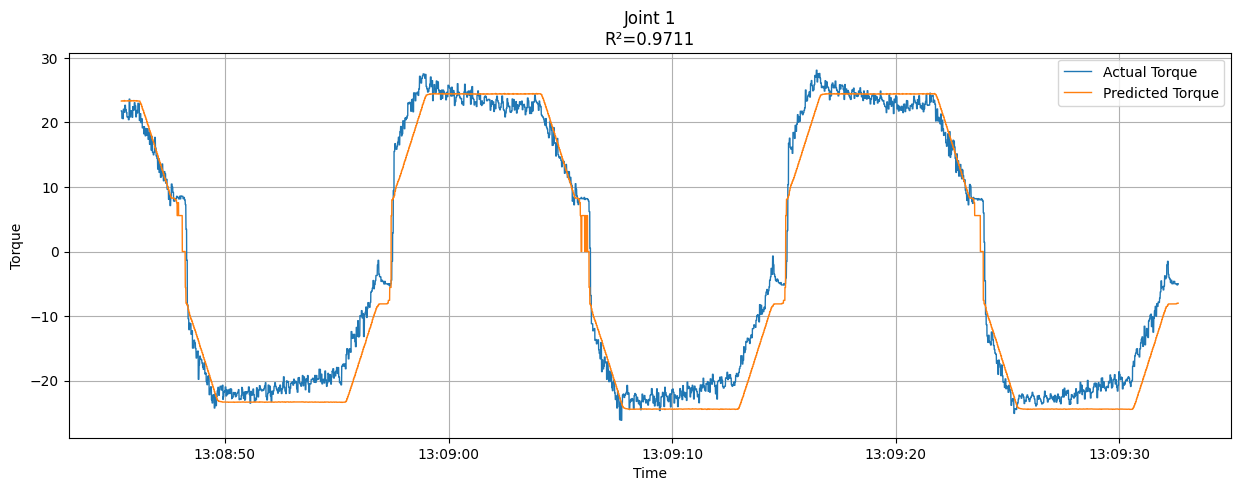

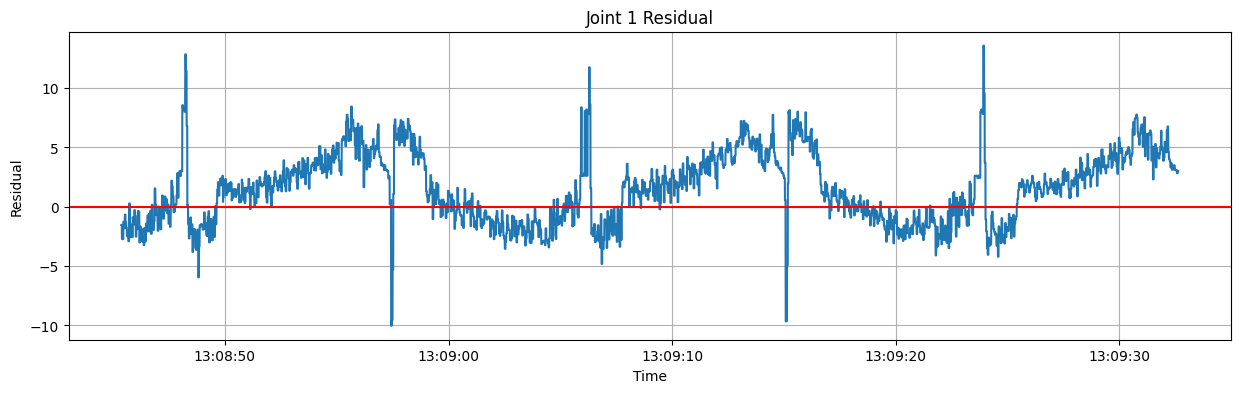

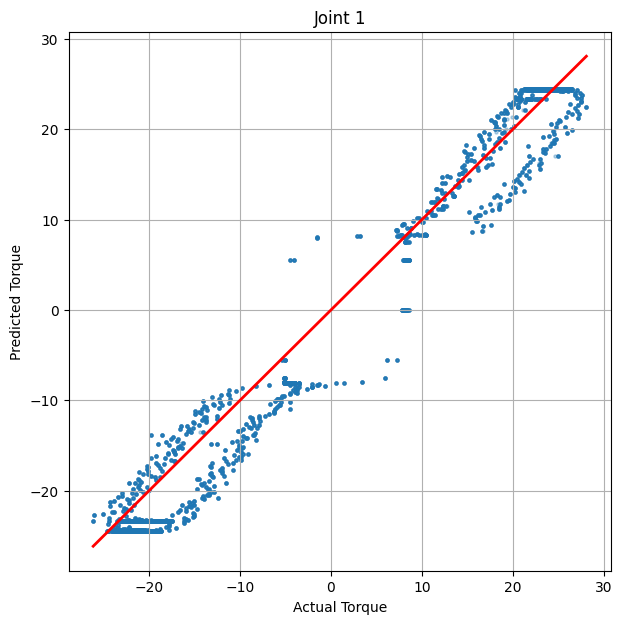

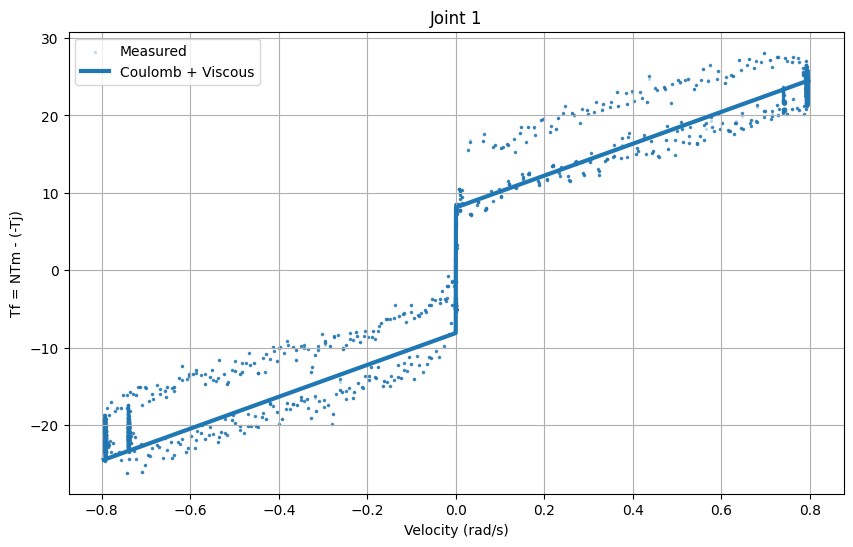


JOINT 2

Tc = 19.605659
Bv = -1.489965
Vs = 0.000235

RMSE = 9.5216
MAE = 8.4564
R² = -0.3450


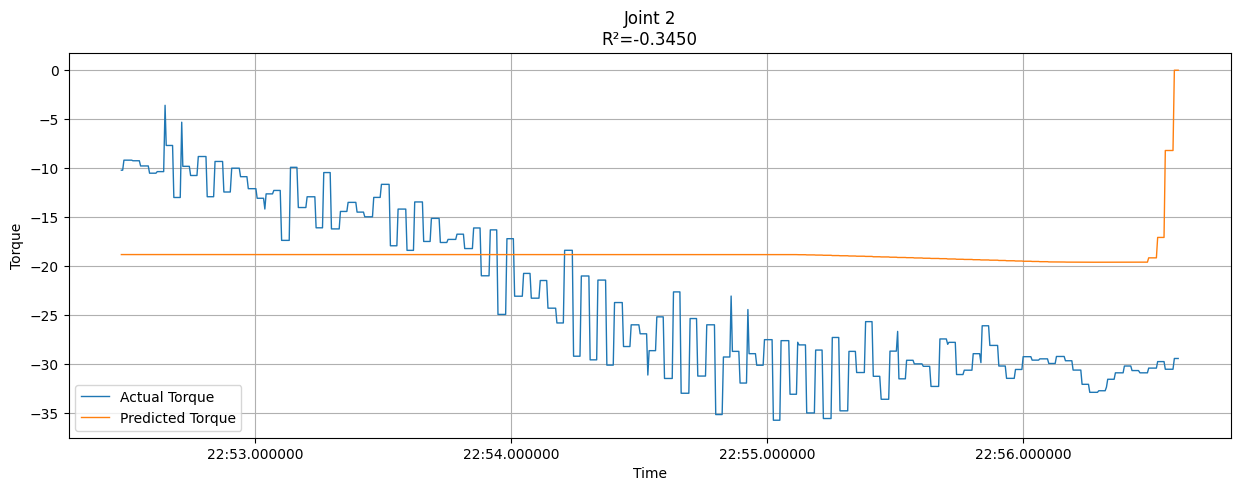

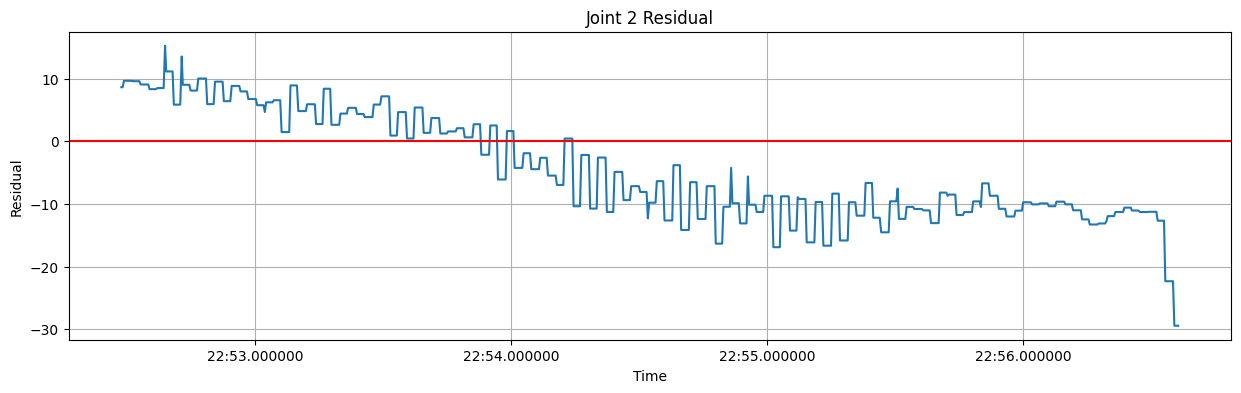

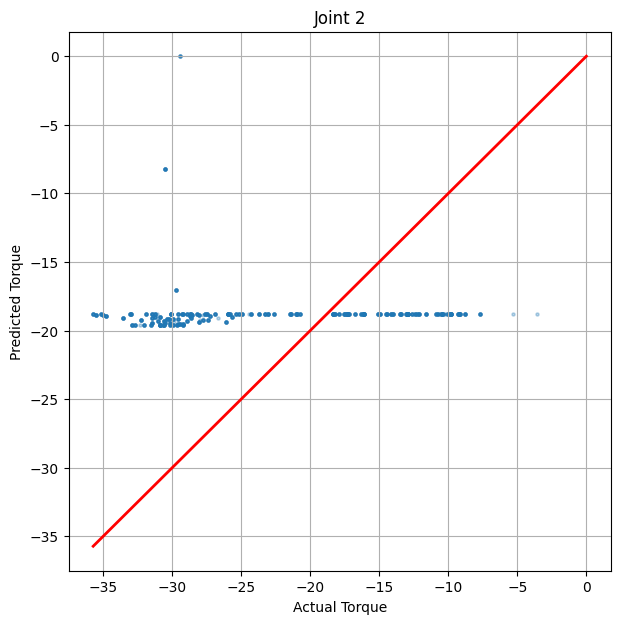

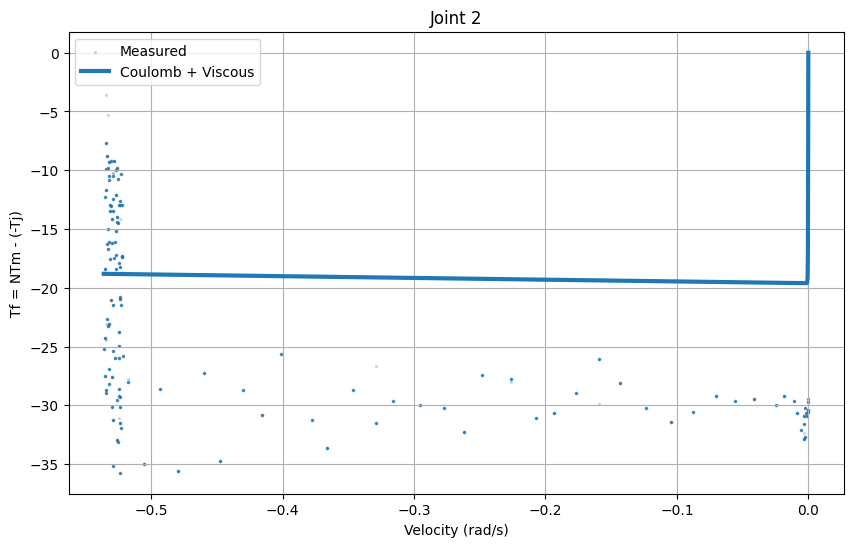


JOINT 3

Tc = 8.869602
Bv = 1.249252
Vs = 0.005730

RMSE = 5.8364
MAE = 4.9516
R² = 0.7489


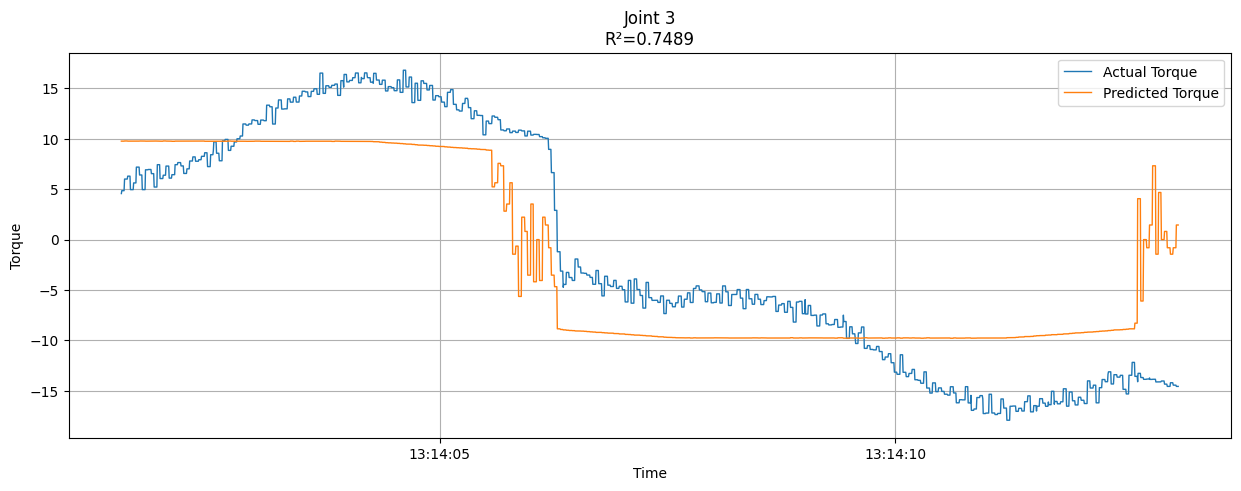

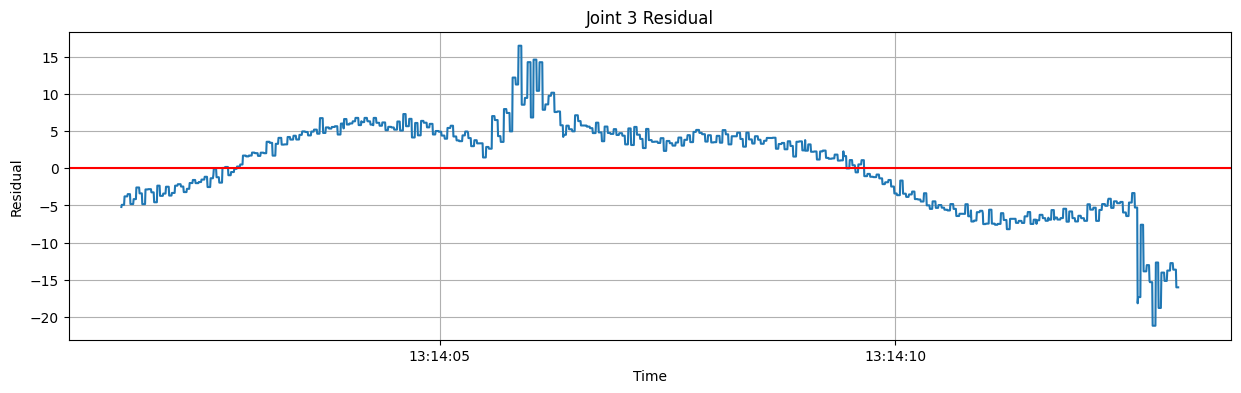

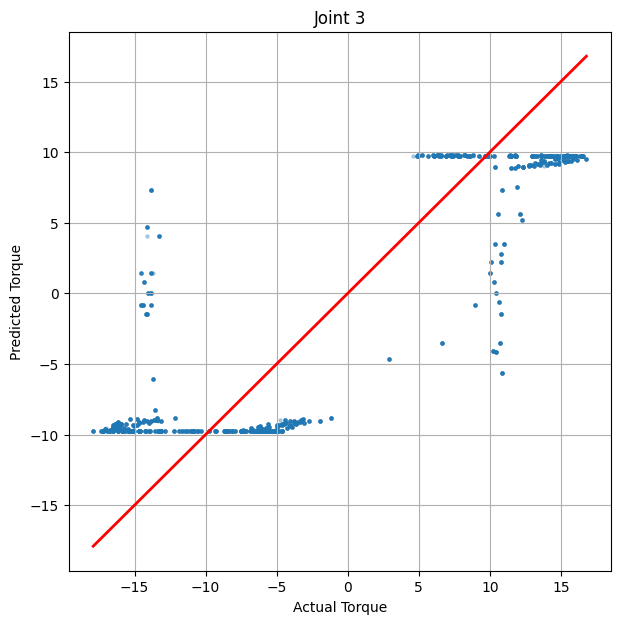

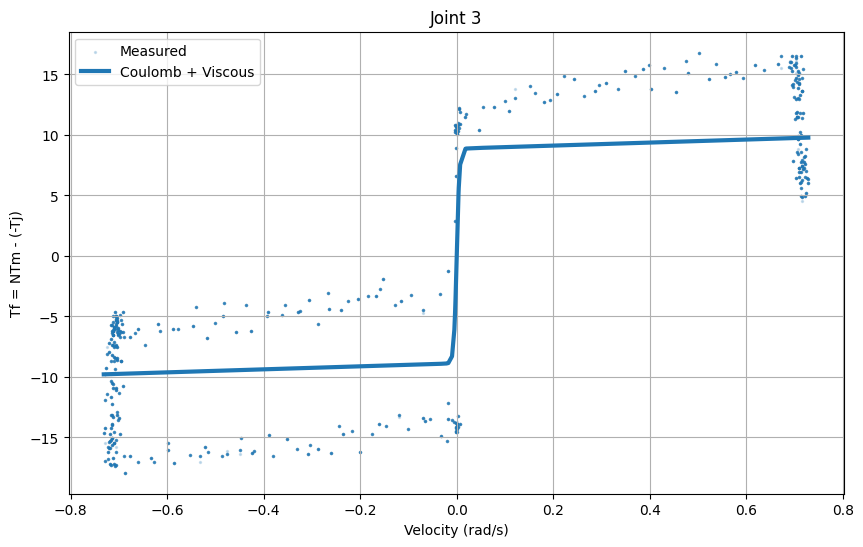


JOINT 5

Tc = 3.081802
Bv = 1.479420
Vs = 0.005131

RMSE = 1.0809
MAE = 0.6595
R² = 0.9226


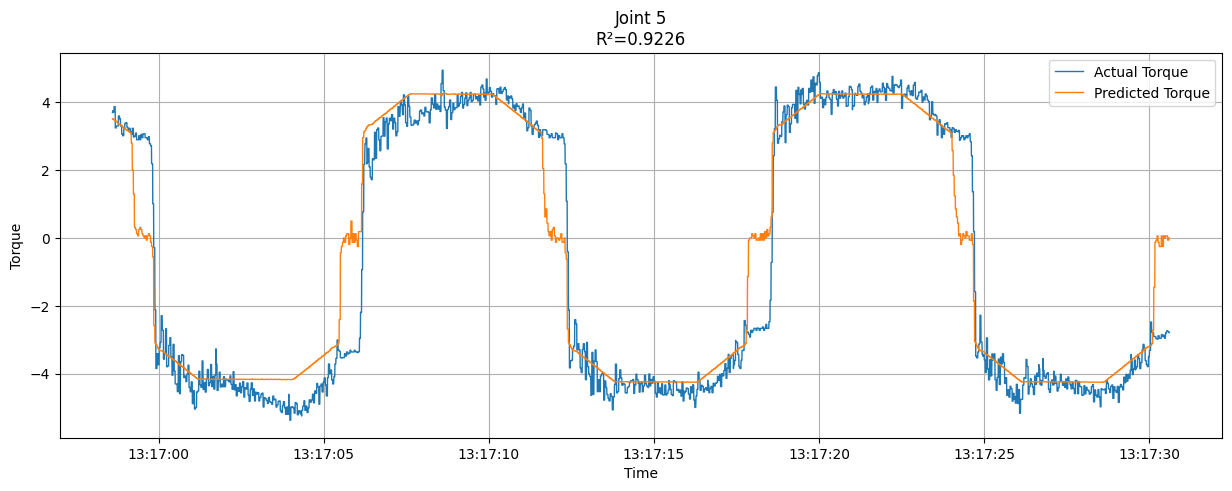

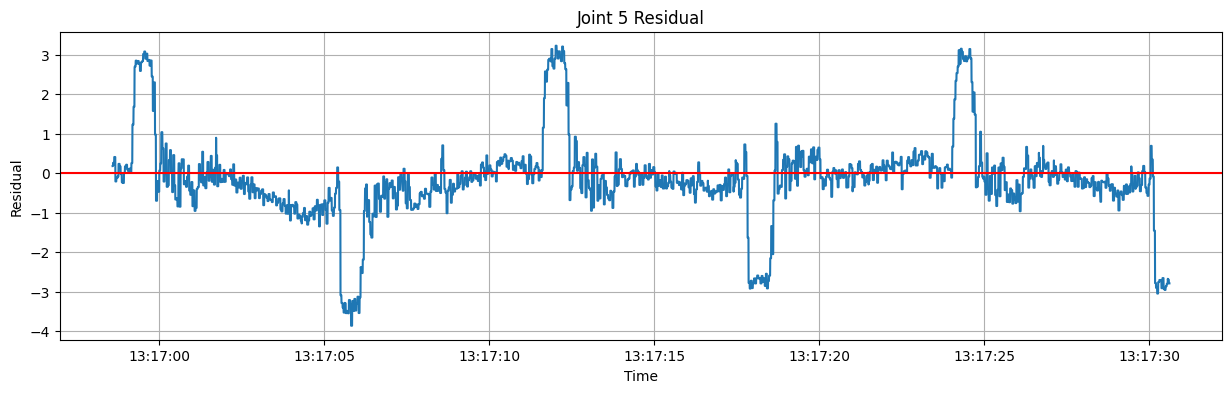

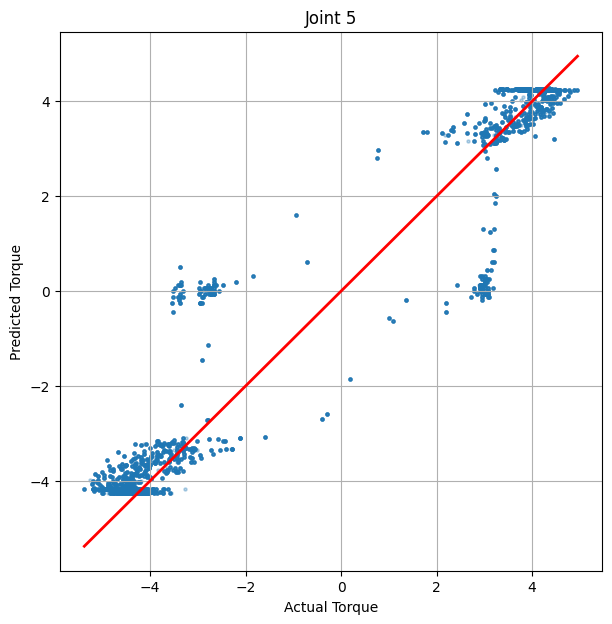

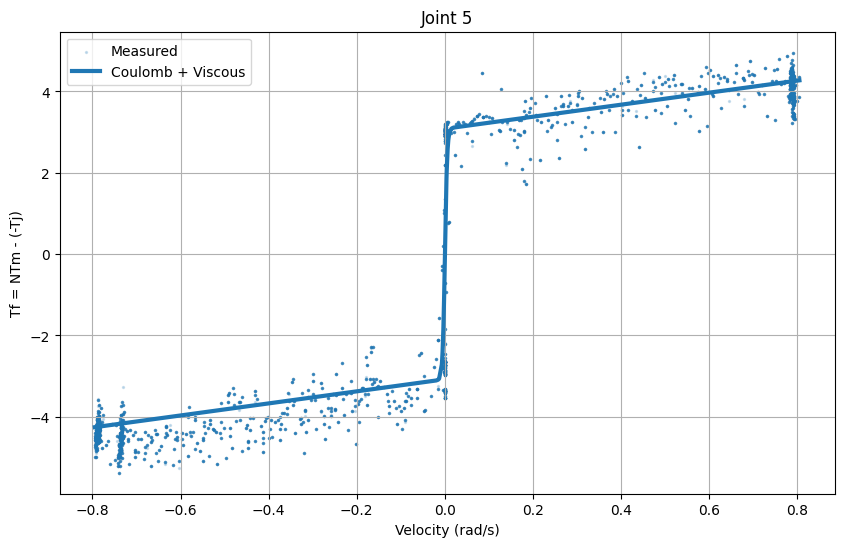

In [4]:
for joint, filename in all_files.items():
    print("\n" + "=" * 70)
    print(f"JOINT {joint}")
    print("=" * 70)
    file_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    # ==========================================
    # TIMESTAMP
    # ==========================================
    df["timestamp"] = pd.to_datetime("2026-06-12 " + df["timestamp"].astype(str))

    # ==========================================
    # COMMON COLUMNS
    # ==========================================
    df["q"] = np.deg2rad(df[f"q{joint}"])
    df["v"] = np.deg2rad(df[f"v{joint}"])
    df["tm"] = df[f"m_t_{joint}"]
    df["tj"] = df[f"jts{joint}"]
    
    # Updated Equation: Tf = NTm - (-Tj)
    df["tf"] = (N * df["tm"] - (-df["tj"]))

    # ==========================================
    # TRAIN / VAL / TEST
    # ==========================================
    size = len(df)
    train_end = int(0.60 * size)
    val_end = int(0.80 * size)
    train_df = df.iloc[ : train_end]
    val_df = df.iloc[train_end : val_end]
    test_df = df.iloc[val_end : ]

    # ==========================================
    # TRAIN
    # ==========================================
    v_train = train_df["v"].values
    tf_train = train_df["tf"].values
    p0 = [5, 0.1, 0.01]
    params, _ = curve_fit(
        friction,
        v_train,
        tf_train,
        p0=p0,
        maxfev=50000
    )
    Tc, Bv, Vs = params
    print()
    print(f"Tc = {Tc:.6f}")
    print(f"Bv = {Bv:.6f}")
    print(f"Vs = {Vs:.6f}")

    # ==========================================
    # TEST
    # ==========================================
    v_test = test_df["v"].values
    tf_test = test_df["tf"].values
    pred = friction(v_test, *params)
    test_time = test_df["timestamp"]
    rmse = np.sqrt(mean_squared_error(tf_test, pred))
    mae = mean_absolute_error(tf_test, pred)
    r2 = r2_score(tf_test, pred)
    print()
    print(f"RMSE = {rmse:.4f}")
    print(f"MAE = {mae:.4f}")
    print(f"R² = {r2:.4f}")

    # ==========================================
    # ACTUAL VS PREDICTED
    # ==========================================
    plt.figure(figsize=(15,5))
    plt.plot(test_time, tf_test, label="Actual Torque", linewidth=1)
    plt.plot(test_time, pred, label="Predicted Torque", linewidth=1)
    plt.title(f"Joint {joint}\nR²={r2:.4f}")
    plt.xlabel("Time")
    plt.ylabel("Torque")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ==========================================
    # RESIDUAL VS TIME
    # ==========================================
    residual = (tf_test - pred)
    plt.figure(figsize=(15,4))
    plt.plot(test_time, residual)
    plt.axhline(0, color="red")
    plt.xlabel("Time")
    plt.ylabel("Residual")
    plt.title(f"Joint {joint} Residual")
    plt.grid(True)
    plt.show()

    # ==========================================
    # ACTUAL VS PREDICTED SCATTER
    # ==========================================
    plt.figure(figsize=(7,7))
    plt.scatter(tf_test, pred, s=5, alpha=0.3)
    mn = min(tf_test.min(), pred.min())
    mx = max(tf_test.max(), pred.max())
    plt.plot([mn,mx], [mn,mx], 'r', linewidth=2)
    plt.xlabel("Actual Torque")
    plt.ylabel("Predicted Torque")
    plt.title(f"Joint {joint}")
    plt.grid(True)
    plt.show()

    # ==========================================
    # FRICTION CURVE
    # ==========================================
    idx = np.argsort(v_test)
    plt.figure(figsize=(10,6))
    plt.scatter(v_test, tf_test, s=2, alpha=0.2, label="Measured")
    plt.plot(v_test[idx], pred[idx], linewidth=3, label="Coulomb + Viscous")
    plt.xlabel("Velocity (rad/s)")
    # Updated label
    plt.ylabel("Tf = NTm - (-Tj)")
    plt.title(f"Joint {joint}")
    plt.legend()
    plt.grid(True)
    plt.show()

# WORK STARTED ON UNIQUE DATA

In [5]:
work_files = {
    1: "1_Unique.csv",
    2: "2_Unique.csv",
    3: "3_Unique.csv",
    5: "5_Unique.csv"
}

In [6]:
def friction_model_unique(v, Tc, Bv, Vs):
    return (Tc * np.tanh(v / Vs) + Bv * v)

results = []


JOINT 1
Columns:
['m_t_1', 'jts1', 'v1', 'q1']

Train : (5396, 1)
Val : (771, 1)
Test : (1542, 1)

Estimated Parameters
Tc = 9.360485071569434
Bv = 17.538634567658082
Vs = 0.0008345799874567691

Validation R² = 0.9815

Performance
RMSE = 2.8382
MAE = 2.0831
R² = 0.9782


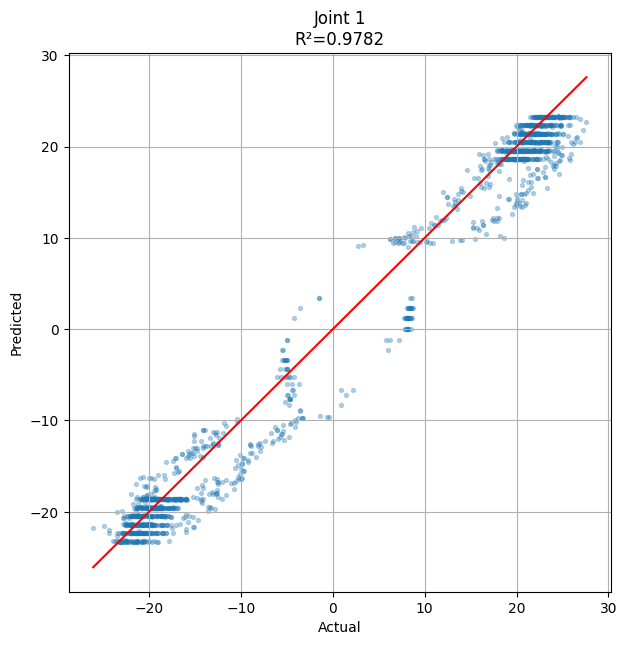

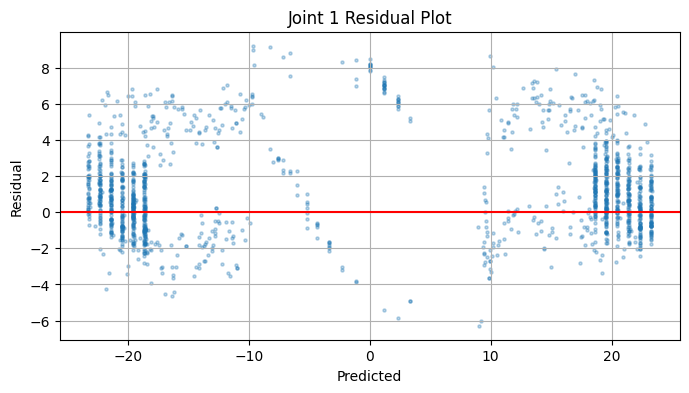

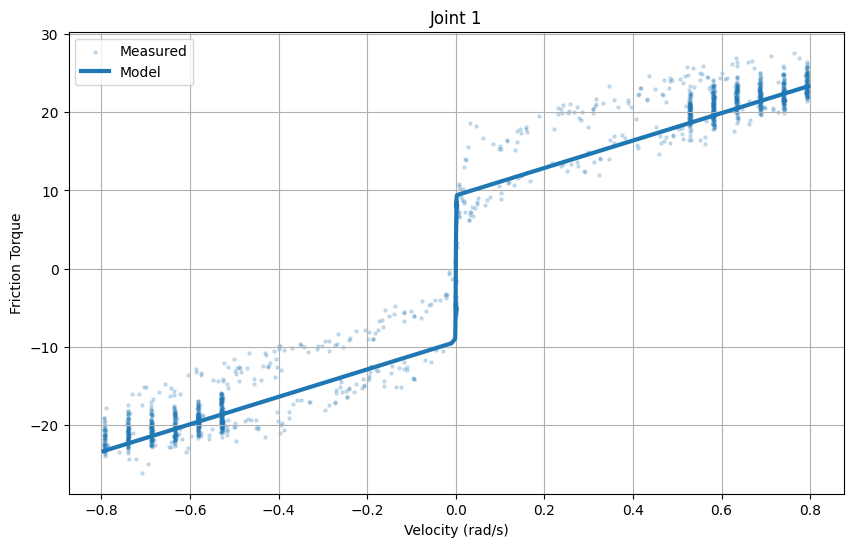


JOINT 2
Columns:
['m_t_2', 'jts2', 'v2', 'q2']

Train : (470, 1)
Val : (67, 1)
Test : (135, 1)

Estimated Parameters
Tc = 21.840128169869107
Bv = -5.457835889491715
Vs = 0.00027246150980126424

Validation R² = 0.8604

Performance
RMSE = 11.3778
MAE = 9.8763
R² = 0.7705


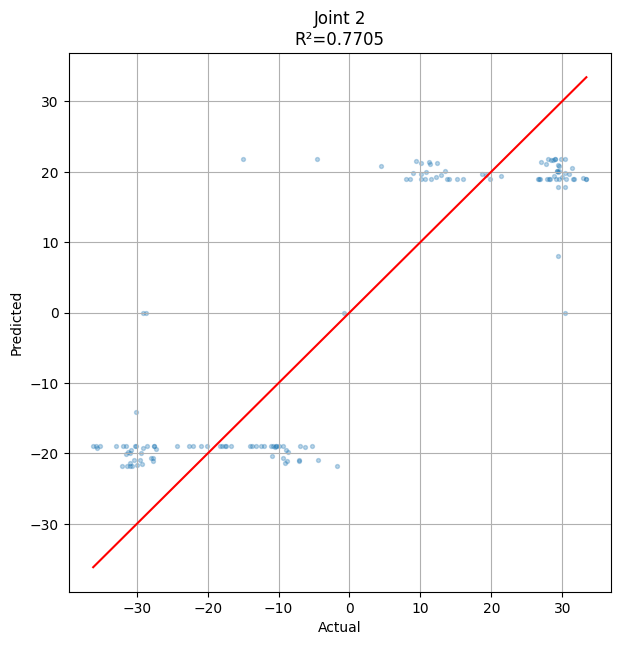

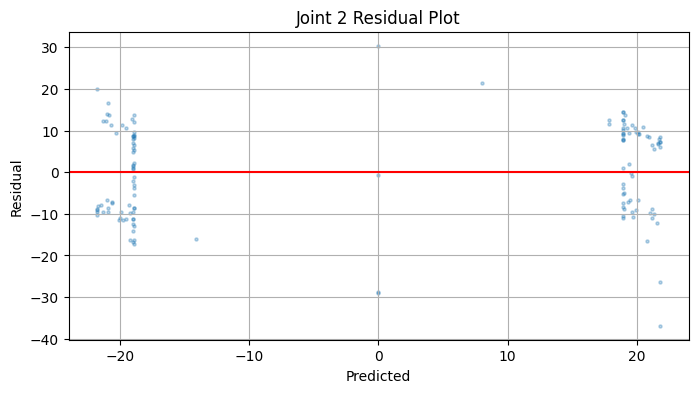

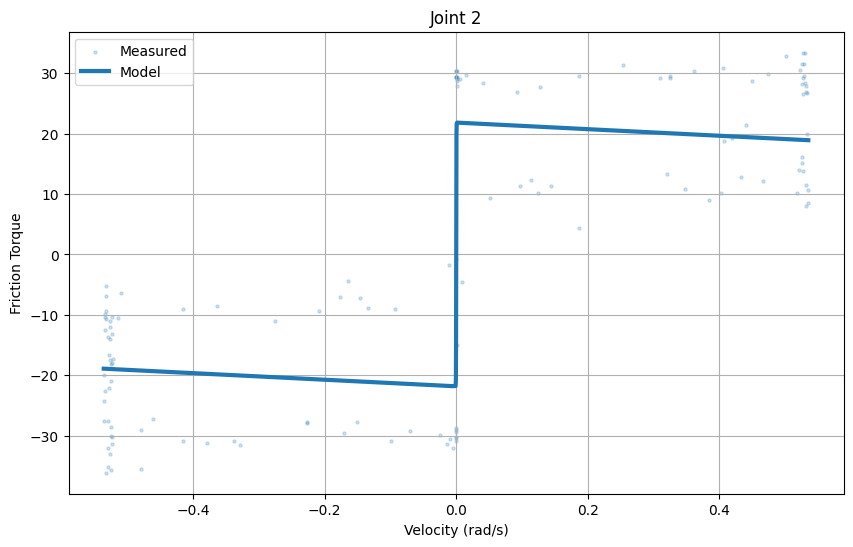


JOINT 3
Columns:
['m_t_3', 'jts3', 'v3', 'q3']

Train : (1337, 1)
Val : (191, 1)
Test : (383, 1)

Estimated Parameters
Tc = 9.277578375842628
Bv = 1.2618550553298504
Vs = 0.007485642495921555

Validation R² = 0.7223

Performance
RMSE = 5.5511
MAE = 4.9423
R² = 0.7262


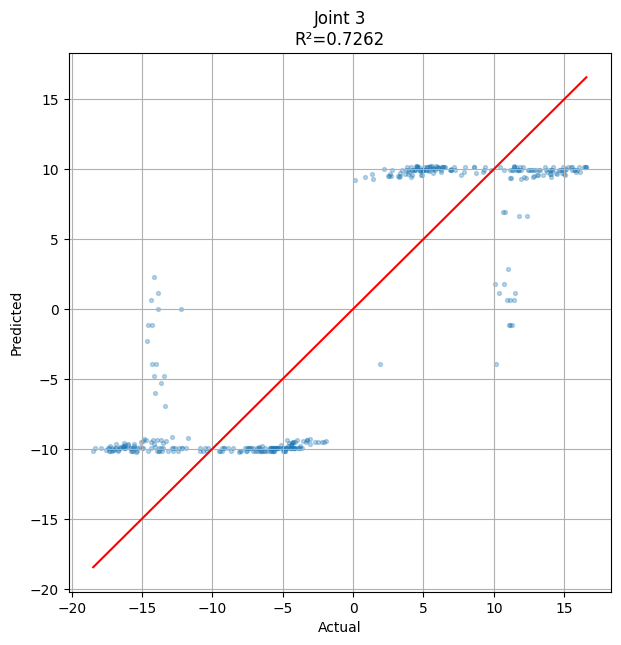

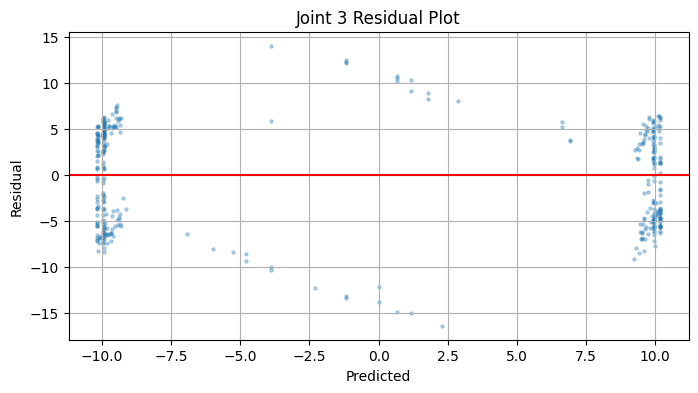

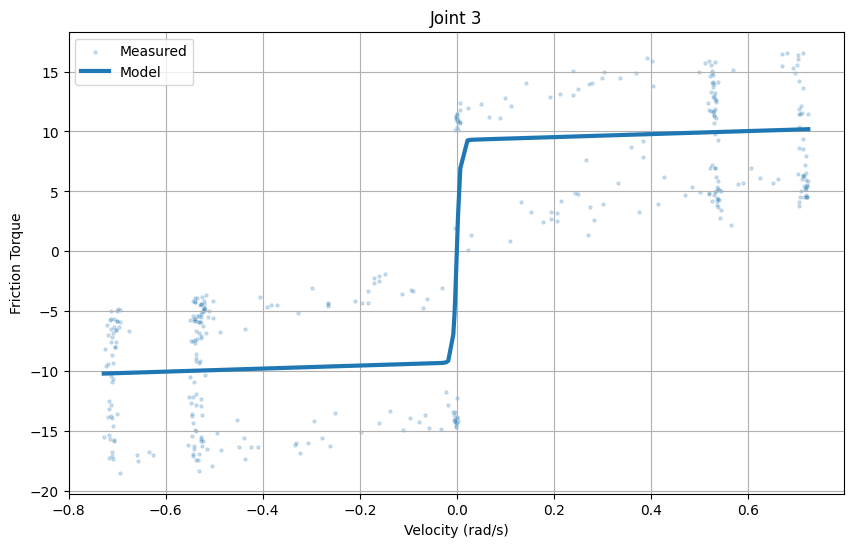


JOINT 5
Columns:
['m_t_5', 'jts5', 'v5', 'q5']

Train : (3663, 1)
Val : (523, 1)
Test : (1047, 1)

Estimated Parameters
Tc = 3.078798104635677
Bv = 1.528935801194213
Vs = 0.004581289891252912

Validation R² = 0.9442

Performance
RMSE = 0.9858
MAE = 0.6017
R² = 0.9326


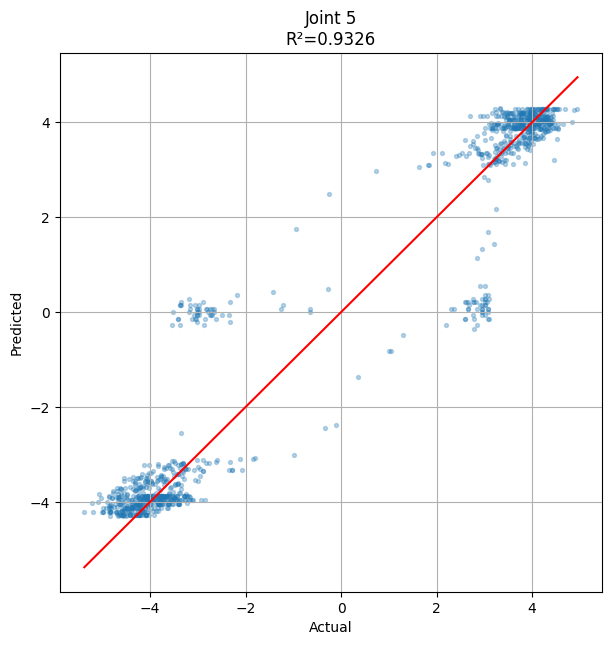

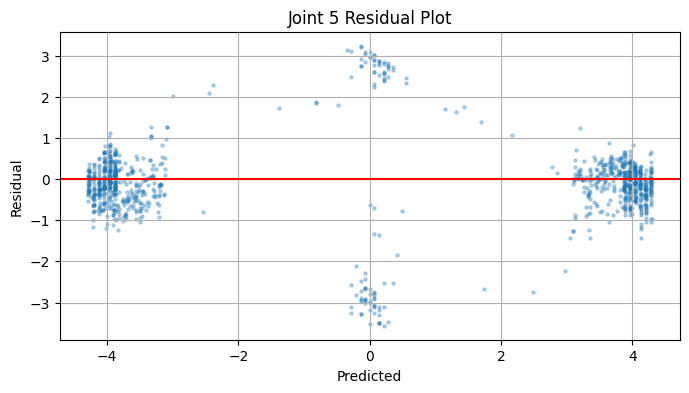

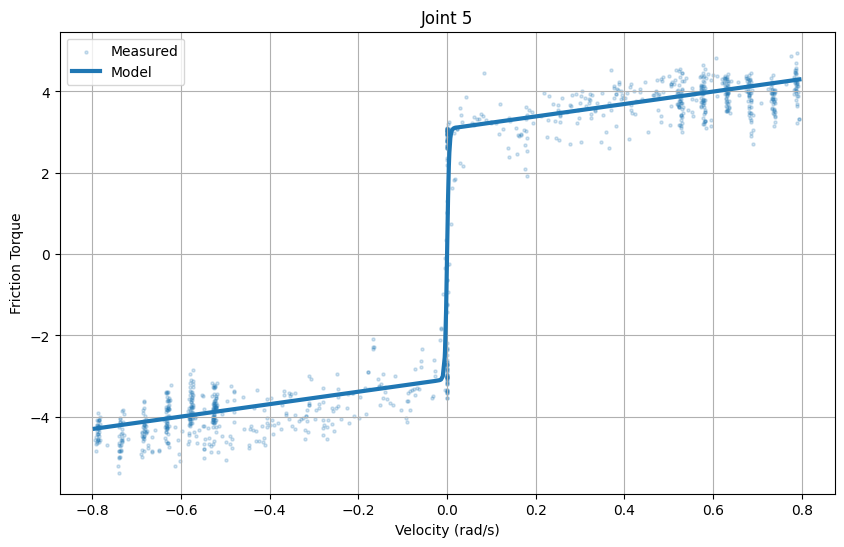

In [7]:
for joint, filename in work_files.items():
    print("\n" + "=" * 70)
    print(f"JOINT {joint}")
    print("="*70)

    # ==========================================
    # LOAD CSV
    # ==========================================
    file_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    print("Columns:")
    print(df.columns.tolist())

    # ==========================================
    # CREATE COMMON COLUMNS
    # ==========================================
    df["v"] = np.deg2rad(df[f"v{joint}"])
    df["q"] = np.deg2rad(df[f"q{joint}"])
    df["tm"] = df[f"m_t_{joint}"]
    df["tj"] = df[f"jts{joint}"]
    df["tf"] = (N * df["tm"] - (-df["tj"]))

    # ==========================================
    # FEATURES & TARGET
    # ==========================================
    X = df[["v"]].values
    y = df["tf"].values

    # ==========================================
    # TRAIN = 70%
    # TEMP  = 30%
    # ==========================================
    (X_train, X_temp, y_train, y_temp) = train_test_split(X, y, test_size=0.30, random_state=42, shuffle=True)

    # ==========================================
    # VAL = 10%
    # TEST = 20%
    # ==========================================
    (X_val, X_test, y_val, y_test) = train_test_split(X_temp, y_temp, test_size=2/3, random_state=42, shuffle=True)
    print()
    print("Train :", X_train.shape)
    print("Val :", X_val.shape)
    print("Test :", X_test.shape)

    # ==========================================
    # FIT MODEL
    # ==========================================
    p0 = [5, 0.1, 0.01]
    params, _ = curve_fit(
        friction_model_unique,
        X_train.ravel(),
        y_train,
        p0=p0,
        maxfev=50000
    )

    Tc, Bv, Vs = params

    print("\nEstimated Parameters")
    print("Tc =", Tc)
    print("Bv =", Bv)
    print("Vs =", Vs)

    # ==========================================
    # VALIDATION
    # ==========================================
    val_pred = friction_model_unique(X_val.ravel(), *params)
    val_r2 = r2_score(y_val, val_pred)
    print(f"\nValidation R² = {val_r2:.4f}")

    # ==========================================
    # TEST
    # ==========================================

    pred = friction_model_unique(X_test.ravel(), *params)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print("\nPerformance")
    print(f"RMSE = {rmse:.4f}")
    print(f"MAE = {mae:.4f}")
    print(f"R² = {r2:.4f}")
    results.append([joint, Tc, Bv, Vs, rmse, mae, r2])

    # ==========================================
    # PLOT 1
    # Actual vs Predicted
    # ==========================================
    plt.figure(figsize=(7,7))
    plt.scatter(y_test, pred, s=8, alpha=0.3)
    mn = min(y_test.min(), pred.min())
    mx = max(y_test.max(), pred.max())
    plt.plot([mn,mx], [mn,mx], 'r')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Joint {joint}\nR²={r2:.4f}")
    plt.grid(True)
    plt.show()

    # ==========================================
    # PLOT 2
    # Residual
    # ==========================================
    residual = (y_test - pred)
    plt.figure(figsize=(8,4))
    plt.scatter(pred, residual, s=5, alpha=0.3)
    plt.axhline(0, color="red")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(f"Joint {joint} Residual Plot")
    plt.grid(True)
    plt.show()

    # ==========================================
    # PLOT 3
    # Friction Curve
    # ==========================================
    idx = np.argsort( X_test.ravel())
    plt.figure(figsize=(10,6))
    plt.scatter(X_test.ravel(), y_test, s=5, alpha=0.2, label="Measured")
    plt.plot(X_test.ravel()[idx], pred[idx], linewidth=3, label="Model")
    plt.xlabel("Velocity (rad/s)")
    plt.ylabel("Friction Torque")
    plt.title(f"Joint {joint}")
    plt.legend()
    plt.grid(True)
    plt.show()